In [12]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Loading the engineered feature set generated in 02_feature_engineering
df = pd.read_csv('../data/processed/FD001_features.csv')
print(f"Engineered dataset loaded successfully. Shape: {df.shape}")

Engineered dataset loaded successfully. Shape: (20631, 89)


In [2]:
# Calculating the exact Remaining Useful Life (RUL) for each cycle
# RUL = max_cycle - current_cycle
max_cycles = df.groupby('unit_id')['cycle'].max().rename('max_cycle')
df = df.join(max_cycles, on='unit_id')
df['RUL_linear'] = df['max_cycle'] - df['cycle']

# Applying a Piecewise Linear model: Capping early RUL values.
# Reason: Engines do not show measurable degradation signs in their early operational cycles.
RUL_CAP = 125
df['RUL'] = df['RUL_linear'].clip(upper=RUL_CAP)

print("Remaining Useful Life (RUL) Target Statistics:")
print(df['RUL'].describe())

Remaining Useful Life (RUL) Target Statistics:
count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64


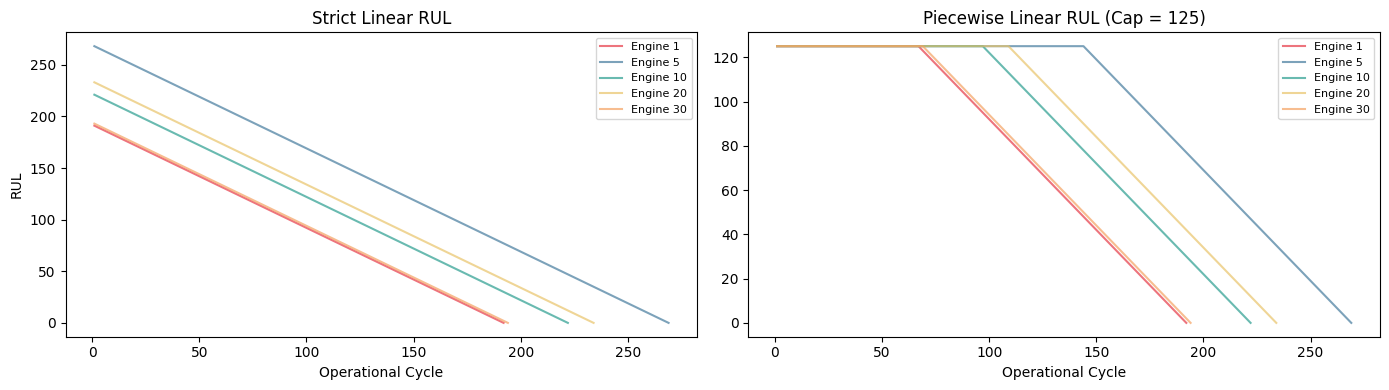

In [3]:
# Plotting the difference between strict Linear RUL and Piecewise Linear RUL for sample engines
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a', '#f4a261']

for i, eng in enumerate([1, 5, 10, 20, 30]):
    sub = df[df['unit_id'] == eng]
    axes[0].plot(sub['cycle'], sub['RUL_linear'], color=colors[i], alpha=0.7, label=f'Engine {eng}')
    axes[1].plot(sub['cycle'], sub['RUL'], color=colors[i], alpha=0.7, label=f'Engine {eng}')

axes[0].set_title('Strict Linear RUL'); axes[0].set_xlabel('Operational Cycle'); axes[0].set_ylabel('RUL')
axes[1].set_title(f'Piecewise Linear RUL (Cap = {RUL_CAP})'); axes[1].set_xlabel('Operational Cycle')
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../results/rul_labels.png', dpi=150)
plt.show()

In [4]:
# Dropping non-predictive administrative columns
drop_cols = ['unit_id', 'max_cycle', 'RUL_linear', 'RUL', 'cycle_norm']
drop_cols = [c for c in drop_cols if c in df.columns]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols]
y = df['RUL']

# Splitting data by specific Engine IDs to ensure the model evaluates on entirely unseen engines
engines = df['unit_id'].unique()
np.random.seed(42)

# Reserving 20% of engines strictly for testing
test_engines = np.random.choice(engines, size=int(0.2 * len(engines)), replace=False)
train_mask = ~df['unit_id'].isin(test_engines)
test_mask  =  df['unit_id'].isin(test_engines)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Training Set Shape: {X_train.shape} | Testing Set Shape: {X_test.shape}")

# Standardizing features to ensure zero mean and unit variance for linear models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Training Set Shape: (16561, 87) | Testing Set Shape: (4070, 87)


In [6]:
def nasa_score(y_true, y_pred):
    """
    Computes NASA's asymmetric scoring metric.
    d = pred - true
    d < 0 (early): exp(-d/13) - 1
    d >= 0 (late):  exp(d/10) - 1
    In aviation, predicting late (overestimating RUL) causes crashes, so it is penalized exponentially higher.
    Predicting early (underestimating RUL) causes early maintenance, penalized slightly less.
    """
    d = np.array(y_pred) - np.array(y_true)
    scores = np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1)
    return np.sum(scores)

def evaluate(name, y_true, y_pred):
    # Calculating standard regression metrics alongside the domain-specific NASA score
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    score = nasa_score(y_true, y_pred)
    
    print(f'{name:20s} | RMSE: {rmse:7.2f} | MAE: {mae:7.2f} | NASA Score: {score:10.1f}')
    return {'Model': name, 'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'NASA_Score': round(score, 1)}

results = []

In [7]:
results = []

# 1. Linear Regression Baseline
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
results.append(evaluate('Linear Regression', y_test, lr.predict(X_test_sc)))

# 2. Ridge Regression (L2 Regularization)
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_sc, y_train)
results.append(evaluate('Ridge Regression', y_test, ridge.predict(X_test_sc)))

# 3. Random Forest Regressor (Non-linear ensemble)
rf = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=5,
                           n_jobs=-1, random_state=42)
rf.fit(X_train, y_train) # Tree-based models do not require scaled data
results.append(evaluate('Random Forest', y_test, rf.predict(X_test)))

# 4. XGBoost Regressor (Advanced Gradient Boosting)
xgb_model = xgb.XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
results.append(evaluate('XGBoost', y_test, xgb_model.predict(X_test)))


Linear Regression    | RMSE:    9.46 | MAE:    7.55 | NASA Score:     5115.3
Ridge Regression     | RMSE:   11.05 | MAE:    8.86 | NASA Score:     6567.2
Random Forest        | RMSE:    1.50 | MAE:    0.74 | NASA Score:      327.5
XGBoost              | RMSE:    1.72 | MAE:    0.99 | NASA Score:      427.2


In [8]:
#Compiling the evaluation results into a benchmark dataframe for analysis
benchmark = pd.DataFrame(results)
benchmark = benchmark.sort_values('RMSE')
benchmark.to_csv('../results/benchmark_table.csv', index=False)
print("\n--- Final Model Benchmark ---")
print(benchmark.to_string(index=False))


--- Final Model Benchmark ---
            Model  RMSE  MAE  NASA_Score
    Random Forest  1.50 0.74       327.5
          XGBoost  1.72 0.99       427.2
Linear Regression  9.46 7.55      5115.3
 Ridge Regression 11.05 8.86      6567.2


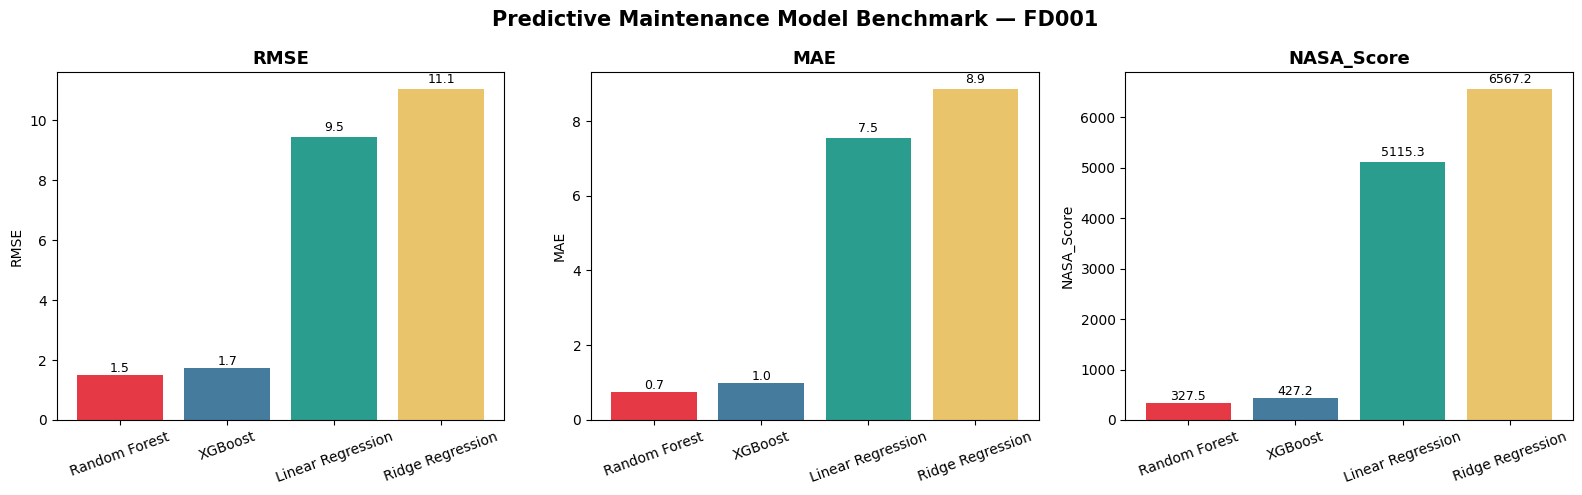

In [9]:
# Plotting comparative performance across evaluated metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a']

for ax, metric in zip(axes, ['RMSE', 'MAE', 'NASA_Score']):
    bars = ax.bar(benchmark['Model'], benchmark[metric], color=palette)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)
    
    # Adding value labels on top of bars
    for bar, val in zip(bars, benchmark[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Predictive Maintenance Model Benchmark — FD001', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/benchmark_chart.png', dpi=150)
plt.show()

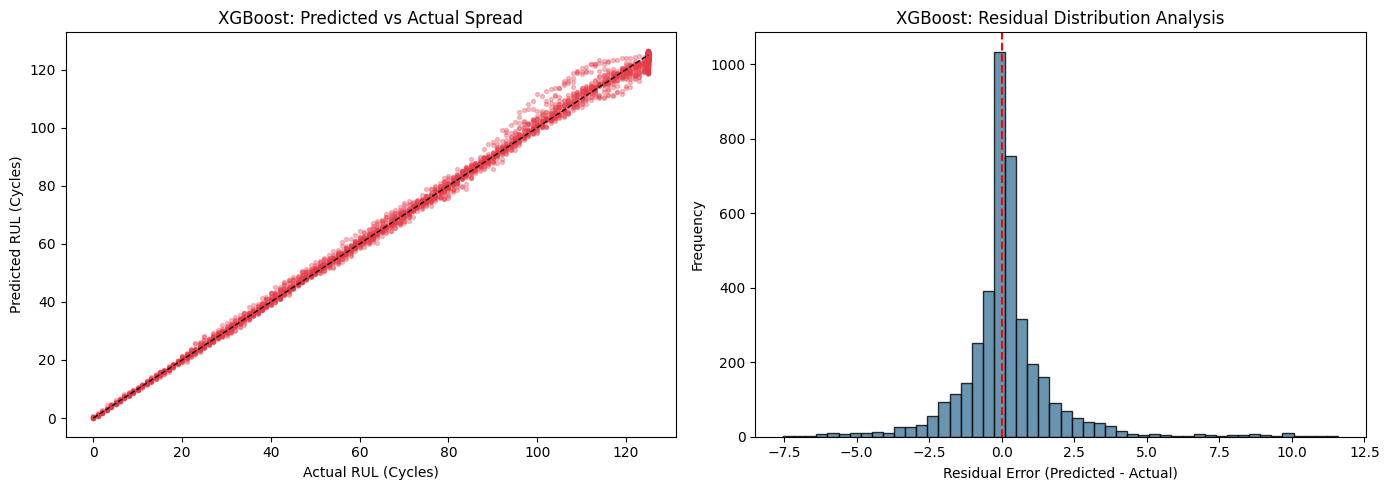

In [10]:
# Evaluating the prediction spread and error distribution of the best-performing model
xgb_preds = xgb_model.predict(X_test)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot of Predicted vs Actual values
axes[0].scatter(y_test, xgb_preds, alpha=0.3, s=8, color='#e63946')
lims = [0, y_test.max()]
axes[0].plot(lims, lims, 'k--', linewidth=1)
axes[0].set_xlabel('Actual RUL (Cycles)'); axes[0].set_ylabel('Predicted RUL (Cycles)')
axes[0].set_title('XGBoost: Predicted vs Actual Spread')

# Histogram of Residuals (Error distribution)
residuals = xgb_preds - y_test.values
axes[1].hist(residuals, bins=50, color='#457b9d', edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual Error (Predicted - Actual)'); axes[1].set_ylabel('Frequency')
axes[1].set_title('XGBoost: Residual Distribution Analysis')

plt.tight_layout()
plt.savefig('../results/xgb_predictions.png', dpi=150)
plt.show()

In [11]:
# Serializing trained models and scalers for deployment in Step 4 and 5
import joblib, os
os.makedirs('../results/models', exist_ok=True)

joblib.dump(lr,       '../results/models/linear_regression.pkl')
joblib.dump(ridge,    '../results/models/ridge.pkl')
joblib.dump(rf,       '../results/models/random_forest.pkl')
joblib.dump(scaler,   '../results/models/scaler.pkl')
xgb_model.save_model('../results/models/xgboost.json')

# Saving feature configurations and the final RUL-labeled dataset
import json
with open('../data/processed/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

df.to_csv('../data/processed/FD001_with_rul.csv', index=False)
print("Pipeline complete. All models, scalers, and datasets have been exported successfully.")

Pipeline complete. All models, scalers, and datasets have been exported successfully.
